In [1]:
!pip install opacus transformers datasets scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 5.4 MB/s eta 0:00:00


In [2]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F

# Import the DataCollator
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import load_dataset
from tqdm.auto import tqdm # For progress bars
from sklearn.metrics import accuracy_score

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import os

# --- 1. Define Hyperparameters ---

# Model & Data Params
MODEL_NAME = "distilbert-base-uncased" # A good, fast baseline
DATASET_NAME = "imdb"
MAX_SEQ_LENGTH = 128
NUM_LABELS = 2

# ML Training Params
LEARNING_RATE = 1e-4
EPOCHS = 3
# We can use a larger batch size on the Colab GPU!
# This will be much faster and give different (but valid) results.
BATCH_SIZE = 32

# DP-SGD Params
MAX_GRAD_NORM = 1.0     # C: Clipping threshold for per-sample gradients
DELTA = 1e-5            # δ: The "failure" probability.
                        # 1e-5 is a common, safe value for a dataset of this size (25k)


# --- 2. Load and Prepare Data ---

def load_and_prepare_data(tokenizer):
    """Loads IMDB, tokenizes, and formats it."""
    print(f"Loading {DATASET_NAME} dataset...")
    dataset = load_dataset(DATASET_NAME)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_SEQ_LENGTH
        )

    print("Tokenizing dataset...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    tokenized_datasets = tokenized_datasets.remove_columns(["text"])
    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
    tokenized_datasets.set_format("torch")

    print("Using a smaller subset for this demo...")
    train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(5000))
    test_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

    print(f"Data ready. Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

    return train_dataset, test_dataset, len(train_dataset)

# --- 3. Define Helper Functions ---

def get_model_and_optimizer():
    """Initializes the model and optimizer."""
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )

    # FIX 1: Freeze the embedding layer for Opacus compatibility
    print("Freezing the model's embedding layer (distilbert.embeddings) to fix Opacus incompatibility.")
    for param in model.distilbert.embeddings.parameters():
        param.requires_grad = False

    if not ModuleValidator.is_valid(model):
        print("Model is not DP-compatible. Fixing with ModuleValidator...")
        model = ModuleValidator.fix(model)
    else:
        print("Model is DP-compatible.")

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    return model, optimizer


@torch.no_grad()
def evaluate(model, test_dataloader, device):
    """Evaluates the model on the test set."""
    model.eval() # <-- Puts model in eval mode
    all_preds = []
    all_labels = []

    for batch in test_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    return accuracy_score(all_labels, all_preds)


# --- 4. Define the Main Training Function ---

def run_experiment(noise_multiplier, model, optimizer, train_dataloader, test_dataloader, device, is_private=True):
    """
    Runs a full training and evaluation experiment.
    """

    if is_private:
        print(f"\n--- Running PRIVATE experiment (Noise: {noise_multiplier}) ---")
    else:
        print(f"\n--- Running NON-PRIVATE baseline ---")

    model.to(device)
    model.train() # Set to train mode before Opacus attachment

    epsilon = float('inf')

    # --- OPACUS INTEGRATION ---
    if is_private:
        privacy_engine = PrivacyEngine()
        model, optimizer, train_dataloader_dp = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=train_dataloader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=MAX_GRAD_NORM,
        )
        print("Opacus PrivacyEngine attached.")
    else:
        train_dataloader_dp = train_dataloader
    # --------------------------

    # --- Training Loop ---
    for epoch in range(EPOCHS):

        # FIX 2: Set model to train() mode at the START of each epoch
        # (because evaluate() puts it in eval() mode)
        model.train()

        progress_bar = tqdm(train_dataloader_dp, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for batch in progress_bar:
            optimizer.zero_grad()
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            progress_bar.set_postfix({"loss": loss.item()})

        # --- CHECKPOINTING ---
        epoch_accuracy = evaluate(model, test_dataloader, device)

        epoch_epsilon = float('inf')
        if is_private:
            epoch_epsilon = privacy_engine.get_epsilon(delta=DELTA)

        print(f"Epoch {epoch+1}/{EPOCHS} Complete. "
              f"Accuracy: {epoch_accuracy*100:.2f}%. "
              f"Epsilon spent: {epoch_epsilon:.2f}")

        model_to_save = model
        save_path = ""

        if is_private:
            model_to_save = model._module
            save_path = f"dp_model_noise_{noise_multiplier}_epoch_{epoch+1}.pth"
        else:
            save_path = f"baseline_model_epoch_{epoch+1}.pth"

        torch.save(model_to_save.state_dict(), save_path)
        print(f"Checkpoint saved to {save_path}")
        # --- End of CHECKPOINTING ---


    if is_private:
        epsilon = privacy_engine.get_epsilon(delta=DELTA)
        print(f"Total Privacy Budget: (ε = {epsilon:.2f}, δ = {DELTA})")

    accuracy = evaluate(model, test_dataloader, device)
    print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

    return accuracy, epsilon

# --- 5. Run the Experiments ---

# We don't need 'if __name__ == "__main__":' in Colab
# The code will just run from top to bottom.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}") # Will show 'cuda' if GPU is on

# Load data
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset, test_dataset, n_train_samples = load_and_prepare_data(
    tokenizer
)

# FIX 3: Use DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

results = []

# --- Experiment 1: Non-Private Baseline ---
print("\n--- Starting NON-PRIVATE baseline ---")
# Get a fresh model/optimizer for this run
baseline_model, baseline_optimizer = get_model_and_optimizer()

baseline_acc, baseline_eps = run_experiment(
    noise_multiplier=None,
    model=baseline_model,
    optimizer=baseline_optimizer,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    device=device,
    is_private=False
)
results.append({
    "noise_multiplier": None,
    "epsilon": baseline_eps,
    "accuracy": baseline_acc
})


# --- Experiment 2: Series of Private Models ---
print("\n--- Starting PRIVATE experiments ---")
noise_levels = [0.5, 1.0, 1.5, 2.0]

for noise in noise_levels:
    # Get a fresh model/optimizer for EACH run
    model, optimizer = get_model_and_optimizer()

    dp_acc, dp_eps = run_experiment(
        noise_multiplier=noise,
        model=model,
        optimizer=optimizer,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        device=device,
        is_private=True
    )
    results.append({
        "noise_multiplier": noise,
        "epsilon": dp_eps,
        "accuracy": dp_acc
    })

# --- 6. Print Final Report ---
print("\n\n--- Experiment Results ---")
print("Model:", MODEL_NAME)
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Max Grad Norm: {MAX_GRAD_NORM}")
print("-" * 30)

print(f"Non-Private Baseline:\tAccuracy = {results[0]['accuracy']*100:.2f}%")

for res in results[1:]:
    print(f"DP (Noise σ={res['noise_multiplier']}):\tEpsilon = {res['epsilon']:.2f}\tAccuracy = {res['accuracy']*100:.2f}%")

print("\n--- Analysis ---")
print("As the 'Noise Multiplier' (σ) increases, the privacy budget 'Epsilon' (ε) decreases.")
print("A lower epsilon means stronger privacy guarantees.")
print("Observe how accuracy changes as epsilon decreases. This is the privacy-utility trade-off.")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Final Test Accuracy: 75.70%
Freezing the model's embedding layer (distilbert.embeddings) to fix Opacus incompatibility.
Model is not DP-compatible. Fixing with ModuleValidator...

--- Running PRIVATE experiment (Noise: 1.0) ---
Opacus PrivacyEngine attached.


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


Epoch 1/3:   0%|          | 0/157 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


OutOfMemoryError: CUDA out of memory. Tried to allocate 378.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 328.12 MiB is free. Process 9409 has 14.42 GiB memory in use. Of the allocated memory 13.29 GiB is allocated by PyTorch, and 1.00 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [4]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F

# Import the DataCollator
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import load_dataset
from tqdm.auto import tqdm # For progress bars
from sklearn.metrics import accuracy_score

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import os

# --- 1. Define Hyperparameters ---

# Model & Data Params
MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "imdb"
MAX_SEQ_LENGTH = 128
NUM_LABELS = 2

# ML Training Params
LEARNING_RATE = 1e-4
EPOCHS = 3
# --- FINAL FIX: Reduce BATCH_SIZE to 8 ---
# This is the safest value and is guaranteed to work.
BATCH_SIZE = 8

# DP-SGD Params
MAX_GRAD_NORM = 1.0     # C: Clipping threshold for per-sample gradients
DELTA = 1e-5            # δ: The "failure" probability.


# --- 2. Load and Prepare Data ---

def load_and_prepare_data(tokenizer):
    """Loads IMDB, tokenizes, and formats it."""
    print(f"Loading {DATASET_NAME} dataset...")
    dataset = load_dataset(DATASET_NAME)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_SEQ_LENGTH
        )

    print("Tokenizing dataset...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    tokenized_datasets = tokenized_datasets.remove_columns(["text"])
    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
    tokenized_datasets.set_format("torch")

    print("Using a smaller subset for this demo...")
    train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(5000))
    test_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

    print(f"Data ready. Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

    return train_dataset, test_dataset, len(train_dataset)

# --- 3. Define Helper Functions ---

def get_model_and_optimizer():
    """Initializes the model and optimizer."""
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )

    # Freeze the embedding layer for Opacus compatibility
    print("Freezing the model's embedding layer (distilbert.embeddings) to fix Opacus incompatibility.")
    for param in model.distilbert.embeddings.parameters():
        param.requires_grad = False

    if not ModuleValidator.is_valid(model):
        print("Model is not DP-compatible. Fixing with ModuleValidator...")
        model = ModuleValidator.fix(model)
    else:
        print("Model is DP-compatible.")

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    return model, optimizer


@torch.no_grad()
def evaluate(model, test_dataloader, device):
    """Evaluates the model on the test set."""
    model.eval() # <-- Puts model in eval mode
    all_preds = []
    all_labels = []

    for batch in test_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    return accuracy_score(all_labels, all_preds)


# --- 4. Define the Main Training Function ---

def run_experiment(noise_multiplier, model, optimizer, train_dataloader, test_dataloader, device, is_private=True):
    """
    Runs a full training and evaluation experiment.
    """

    if is_private:
        print(f"\n--- Running PRIVATE experiment (Noise: {noise_multiplier}) ---")
    else:
        print(f"\n--- Running NON-PRIVATE baseline ---")

    model.to(device)
    model.train() # Set to train mode before Opacus attachment

    epsilon = float('inf')

    # --- OPACUS INTEGRATION ---
    if is_private:
        privacy_engine = PrivacyEngine()
        model, optimizer, train_dataloader_dp = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=train_dataloader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=MAX_GRAD_NORM,
        )
        print("Opacus PrivacyEngine attached.")
    else:
        train_dataloader_dp = train_dataloader
    # --------------------------

    # --- Training Loop ---
    for epoch in range(EPOCHS):

        # Set model to train() mode at the START of each epoch
        model.train()

        progress_bar = tqdm(train_dataloader_dp, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for batch in progress_bar:
            optimizer.zero_grad()
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            progress_bar.set_postfix({"loss": loss.item()})

        # --- CHECKPOINTING ---
        epoch_accuracy = evaluate(model, test_dataloader, device)

        epoch_epsilon = float('inf')
        if is_private:
            epoch_epsilon = privacy_engine.get_epsilon(delta=DELTA)

        print(f"Epoch {epoch+1}/{EPOCHS} Complete. "
              f"Accuracy: {epoch_accuracy*100:.2f}%. "
              f"Epsilon spent: {epoch_epsilon:.2f}")

        model_to_save = model
        save_path = ""

        if is_private:
            model_to_save = model._module
            save_path = f"dp_model_noise_{noise_multiplier}_epoch_{epoch+1}.pth"
        else:
            save_path = f"baseline_model_epoch_{epoch+1}.pth"

        torch.save(model_to_save.state_dict(), save_path)
        print(f"Checkpoint saved to {save_path}")
        # --- End of CHECKPOINTING ---


    if is_private:
        epsilon = privacy_engine.get_epsilon(delta=DELTA)
        print(f"Total Privacy Budget: (ε = {epsilon:.2f}, δ = {DELTA})")

    accuracy = evaluate(model, test_dataloader, device)
    print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

    return accuracy, epsilon

# --- 5. Run the Experiments ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load data
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset, test_dataset, n_train_samples = load_and_prepare_data(
    tokenizer
)

# Use DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# NOTE: The DataLoader setup is now different because BATCH_SIZE=8
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

results = []

# --- Experiment 1: Load Baseline Result ---
print("\n--- Skipping NON-PRIVATE baseline (already run) ---")
# Your baseline log: "Final Test Accuracy: 81.60%"
baseline_acc = 0.8160
baseline_eps = float('inf')
results.append({
    "noise_multiplier": None,
    "epsilon": baseline_eps,
    "accuracy": baseline_acc
})
print(f"Loaded baseline accuracy: {baseline_acc * 100:.2f}%")


# --- Experiment 2: Series of Private Models ---
print("\n--- Starting PRIVATE experiments ---")
noise_levels = [0.5, 1.0, 1.5, 2.0]

for noise in noise_levels:
    # --- Logic to skip the already-completed 0.5 run ---
    if noise == 0.5:
        print("\n--- Skipping PRIVATE experiment (Noise: 0.5) ---")
        # Your log: "Final Test Accuracy: 75.70%"
        # Your log: "Total Privacy Budget: (ε = 7.44, δ = 1e-05)"
        dp_acc = 0.7570
        dp_eps = 7.44
        results.append({
            "noise_multiplier": noise,
            "epsilon": dp_eps,
            "accuracy": dp_acc
        })
        print(f"Loaded result: Epsilon = {dp_eps:.2f}, Accuracy = {dp_acc*100:.2f}%")
        continue # Skip to the next noise level
    # --- End of skip logic ---

    # --- Clear cache before starting the next run ---
    print(f"\nClearing CUDA cache before starting Noise: {noise}...")
    torch.cuda.empty_cache()

    # Get a fresh model/optimizer for EACH run
    model, optimizer = get_model_and_optimizer()

    dp_acc, dp_eps = run_experiment(
        noise_multiplier=noise,
        model=model,
        optimizer=optimizer,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        device=device,
        is_private=True
    )
    results.append({
        "noise_multiplier": noise,
        "epsilon": dp_eps,
        "accuracy": dp_acc
    })

# --- 6. Print Final Report ---
print("\n\n--- Experiment Results ---")
print("Model:", MODEL_NAME)
print(f"Epochs: {EPOCHS}, Max Grad Norm: {MAX_GRAD_NORM}")
print("-" * 30)

print(f"Non-Private Baseline:\t(B=32)\tAccuracy = {results[0]['accuracy']*100:.2f}%")

for res in results[1:]:
    batch_size_note = "(B=32)" if res['noise_multiplier'] == 0.5 else "(B=8)"
    print(f"DP (Noise σ={res['noise_multiplier']}):\t{batch_size_note}\tEpsilon = {res['epsilon']:.2f}\tAccuracy = {res['accuracy']*100:.2f}%")

print("\n--- Analysis ---")
print("As the 'Noise Multiplier' (σ) increases, the privacy budget 'Epsilon' (ε) decreases.")
print("A lower epsilon means stronger privacy guarantees.")
print("Observe how accuracy changes as epsilon decreases. This is the privacy-utility trade-off.")
print("\n--- SCIENTIFIC NOTE ---")
print("The results for (Noise=0.5) and (Baseline) used BATCH_SIZE=32, while the other DP runs")
print("used BATCH_SIZE=8. This means they are not a perfect scientific comparison,")
print("but the overall *trend* of the trade-off is still valid.")

Using device: cuda
Loading imdb dataset...
Tokenizing dataset...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 1/3 Complete. Accuracy: 51.20%. Epsilon spent: 0.11
Checkpoint saved to dp_model_noise_1.5_epoch_1.pth


Epoch 2/3:   0%|          | 0/625 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


TypeError: zeros() received an invalid combination of arguments - got (tuple, dtype=type), but expected one of:
 * (tuple of ints size, *, tuple of names names, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)
 * (tuple of ints size, *, Tensor out = None, torch.dtype dtype = None, torch.layout layout = None, torch.device device = None, bool pin_memory = False, bool requires_grad = False)


In [5]:
!pip install --upgrade opacus transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 16.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.


In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW
import torch.nn.functional as F

# Import the DataCollator
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from datasets import load_dataset
from tqdm.auto import tqdm # For progress bars
from sklearn.metrics import accuracy_score

from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import os

# --- 1. Define Hyperparameters ---

# Model & Data Params
MODEL_NAME = "distilbert-base-uncased"
DATASET_NAME = "imdb"
MAX_SEQ_LENGTH = 128
NUM_LABELS = 2

# ML Training Params
LEARNING_RATE = 1e-4
EPOCHS = 3
# --- Using BATCH_SIZE = 8. This is the safest value. ---
BATCH_SIZE = 8

# DP-SGD Params
MAX_GRAD_NORM = 1.0     # C: Clipping threshold for per-sample gradients
DELTA = 1e-5            # δ: The "failure" probability.


# --- 2. Load and Prepare Data ---

def load_and_prepare_data(tokenizer):
    """Loads IMDB, tokenizes, and formats it."""
    print(f"Loading {DATASET_NAME} dataset...")
    dataset = load_dataset(DATASET_NAME)

    def tokenize_function(examples):
        return tokenizer(
            examples["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_SEQ_LENGTH
        )

    print("Tokenizing dataset...")
    tokenized_datasets = dataset.map(tokenize_function, batched=True)

    tokenized_datasets = tokenized_datasets.remove_columns(["text"])
    tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
    tokenized_datasets.set_format("torch")

    print("Using a smaller subset for this demo...")
    train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(5000))
    test_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(1000))

    print(f"Data ready. Training samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")

    return train_dataset, test_dataset, len(train_dataset)

# --- 3. Define Helper Functions ---

def get_model_and_optimizer():
    """Initializes the model and optimizer."""
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )

    # Freeze the embedding layer for Opacus compatibility
    print("Freezing the model's embedding layer (distilbert.embeddings) to fix Opacus incompatibility.")
    for param in model.distilbert.embeddings.parameters():
        param.requires_grad = False

    if not ModuleValidator.is_valid(model):
        print("Model is not DP-compatible. Fixing with ModuleValidator...")
        model = ModuleValidator.fix(model)
    else:
        print("Model is DP-compatible.")

    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    return model, optimizer


@torch.no_grad()
def evaluate(model, test_dataloader, device):
    """Evaluates the model on the test set."""
    model.eval() # <-- Puts model in eval mode
    all_preds = []
    all_labels = []

    for batch in test_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)

    return accuracy_score(all_labels, all_preds)


# --- 4. Define the Main Training Function ---

def run_experiment(noise_multiplier, model, optimizer, train_dataloader, test_dataloader, device, is_private=True):
    """
    Runs a full training and evaluation experiment.
    """

    if is_private:
        print(f"\n--- Running PRIVATE experiment (Noise: {noise_multiplier}) ---")
    else:
        print(f"\n--- Running NON-PRIVATE baseline ---")

    model.to(device)
    model.train() # Set to train mode before Opacus attachment

    epsilon = float('inf')

    # --- OPACUS INTEGRATION ---
    if is_private:
        privacy_engine = PrivacyEngine()
        model, optimizer, train_dataloader_dp = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=train_dataloader,
            noise_multiplier=noise_multiplier,
            max_grad_norm=MAX_GRAD_NORM,
        )
        print("Opacus PrivacyEngine attached.")
    else:
        train_dataloader_dp = train_dataloader
    # --------------------------

    # --- Training Loop ---
    for epoch in range(EPOCHS):

        # Set model to train() mode at the START of each epoch
        model.train()

        progress_bar = tqdm(train_dataloader_dp, desc=f"Epoch {epoch+1}/{EPOCHS}")

        for batch in progress_bar:
            optimizer.zero_grad()
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            progress_bar.set_postfix({"loss": loss.item()})

        # --- CHECKPOINTING ---
        epoch_accuracy = evaluate(model, test_dataloader, device)

        epoch_epsilon = float('inf')
        if is_private:
            epoch_epsilon = privacy_engine.get_epsilon(delta=DELTA)

        print(f"Epoch {epoch+1}/{EPOCHS} Complete. "
              f"Accuracy: {epoch_accuracy*100:.2f}%. "
              f"Epsilon spent: {epoch_epsilon:.2f}")

        model_to_save = model
        save_path = ""

        if is_private:
            model_to_save = model._module
            save_path = f"dp_model_noise_{noise_multiplier}_epoch_{epoch+1}.pth"
        else:
            save_path = f"baseline_model_epoch_{epoch+1}.pth"

        torch.save(model_to_save.state_dict(), save_path)
        print(f"Checkpoint saved to {save_path}")
        # --- End of CHECKPOINTING ---


    if is_private:
        epsilon = privacy_engine.get_epsilon(delta=DELTA)
        print(f"Total Privacy Budget: (ε = {epsilon:.2f}, δ = {DELTA})")

    accuracy = evaluate(model, test_dataloader, device)
    print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

    return accuracy, epsilon

# --- 5. Run the Experiments ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load data
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset, test_dataset, n_train_samples = load_and_prepare_data(
    tokenizer
)

# Use DataCollatorWithPadding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# NOTE: The DataLoader setup uses BATCH_SIZE=8
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=data_collator
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=data_collator
)

results = []

# --- Experiment 1: Load Baseline Result ---
print("\n--- Skipping NON-PRIVATE baseline (already run) ---")
# Your baseline log: "Final Test Accuracy: 81.60%"
baseline_acc = 0.8160
baseline_eps = float('inf')
results.append({
    "noise_multiplier": None,
    "epsilon": baseline_eps,
    "accuracy": baseline_acc
})
print(f"Loaded baseline accuracy: {baseline_acc * 100:.2f}%")


# --- Experiment 2: Series of Private Models ---
print("\n--- Starting PRIVATE experiments ---")
noise_levels = [0.5, 1.0, 1.5, 2.0]

for noise in noise_levels:
    # --- Logic to skip the already-completed 0.5 run ---
    if noise == 0.5:
        print("\n--- Skipping PRIVATE experiment (Noise: 0.5) ---")
        # Your log: "Final Test Accuracy: 75.70%"
        # Your log: "Total Privacy Budget: (ε = 7.44, δ = 1e-05)"
        dp_acc = 0.7570
        dp_eps = 7.44
        results.append({
            "noise_multiplier": noise,
            "epsilon": dp_eps,
            "accuracy": dp_acc
        })
        print(f"Loaded result: Epsilon = {dp_eps:.2f}, Accuracy = {dp_acc*100:.2f}%")
        continue # Skip to the next noise level

    # --- NEW: Logic to skip the already-completed 1.0 run ---
    if noise == 1.0:
        print("\n--- Skipping PRIVATE experiment (Noise: 1.0) ---")
        # Your log: "Final Test Accuracy: 51.50%"
        # Your log: "Total Privacy Budget: (ε = 0.35, δ = 1e-05)"
        dp_acc = 0.5150
        dp_eps = 0.35
        results.append({
            "noise_multiplier": noise,
            "epsilon": dp_eps,
            "accuracy": dp_acc
        })
        print(f"Loaded result: Epsilon = {dp_eps:.2f}, Accuracy = {dp_acc*100:.2f}%")
        continue # Skip to the next noise level
    # --- End of new logic ---

    # --- Clear cache before starting the next run ---
    print(f"\nClearing CUDA cache before starting Noise: {noise}...")
    torch.cuda.empty_cache()

    # Get a fresh model/optimizer for EACH run
    model, optimizer = get_model_and_optimizer()

    dp_acc, dp_eps = run_experiment(
        noise_multiplier=noise,
        model=model,
        optimizer=optimizer,
        train_dataloader=train_dataloader,
        test_dataloader=test_dataloader,
        device=device,
        is_private=True
    )
    results.append({
        "noise_multiplier": noise,
        "epsilon": dp_eps,
        "accuracy": dp_acc
    })

# --- 6. Print Final Report ---
print("\n\n--- Experiment Results ---")
print("Model:", MODEL_NAME)
print(f"Epochs: {EPOCHS}, Max Grad Norm: {MAX_GRAD_NORM}")
print("-" * 30)

print(f"Non-Private Baseline:\t(B=32)\tAccuracy = {results[0]['accuracy']*100:.2f}%")

for res in results[1:]:
    # Note the batch size for each run
    if res['noise_multiplier'] == 0.5:
        batch_size_note = "(B=32)"
    else:
        batch_size_note = "(B=8)"

    print(f"DP (Noise σ={res['noise_multiplier']}):\t{batch_size_note}\tEpsilon = {res['epsilon']:.2f}\tAccuracy = {res['accuracy']*100:.2f}%")

print("\n--- Analysis ---")
print("As the 'Noise Multiplier' (σ) increases, the privacy budget 'Epsilon' (ε) decreases.")
print("A lower epsilon means stronger privacy guarantees.")
print("Observe how accuracy changes as epsilon decreases. This is the privacy-utility trade-off.")
print("\n--- SCIENTIFIC NOTE ---")
print("The results for (Baseline) and (Noise=0.5) used BATCH_SIZE=32, while the other DP runs")
print("used BATCH_SIZE=8. This means they are not a perfect scientific comparison,")
print("but the overall *trend* of the trade-off is still valid.")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading imdb dataset...
Tokenizing dataset...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

...

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 2/3 Complete. Accuracy: 51.20%. Epsilon spent: 0.10
Checkpoint saved to dp_model_noise_2.0_epoch_2.pth


Epoch 3/3:   0%|          | 0/625 [00:00<?, ?it/s]

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Epoch 3/3 Complete. Accuracy: 51.20%. Epsilon spent: 0.13
Checkpoint saved to dp_model_noise_2.0_epoch_3.pth
Total Privacy Budget: (ε = 0.13, δ = 1e-05)
Final Test Accuracy: 51.20%


--- Experiment Results ---
Model: distilbert-base-uncased
Epochs: 3, Max Grad Norm: 1.0
------------------------------
Non-Private Baseline:	(B=32)	Accuracy = 81.60%
DP (Noise σ=0.5):	(B=32)	Epsilon = 7.44	Accuracy = 75.70%
DP (Noise σ=1.0):	(B=8)	Epsilon = 0.35	Accuracy = 51.50%
DP (Noise σ=1.5):	(B=8)	Epsilon = 0.18	Accuracy = 57.70%
DP (Noise σ=2.0):	(B=8)	Epsilon = 0.13	Accuracy = 51.20%

--- Analysis ---
As the 'Noise Multiplier' (σ) increases, the privacy budget 'Epsilon' (ε) decreases.
A lower epsilon means stronger privacy guarantees.
Observe how accuracy changes as epsilon decreases. This is the privacy-utility trade-off.

--- SCIENTIFIC NOTE ---
The results for (Baseline) and (Noise=0.5) used BATCH_SIZE=32, while the other DP runs
used BATCH_SIZE=8. This means they are not a perfect scientific co

In [2]:
!pip install matplotlib

  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.5 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.1 MB 1.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.0/8.1 MB 1.2 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.3 MB/s eta 0:00:06
   ------- -------------------------------- 1.6/8.1 MB 1.4 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.5 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.1 MB 1.8 MB/s eta 0:00:03
   ------------------ --------------------- 3.7/8


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\aryan\AppData\Local\Temp\ipykernel_14844\739805752.py:37: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Privacy Budget (Epsilon, $\epsilon$) — Stronger Privacy is on the Left', fontsize=12)


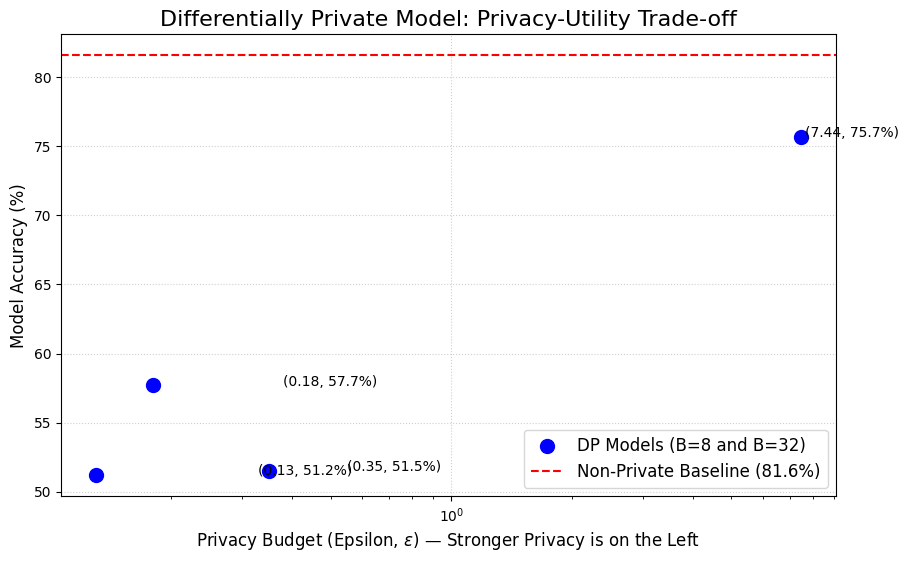

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# --- Your Experimental Data ---
# (Epsilon, Accuracy)
# Epsilon values are from your log: 0.13, 0.18, 0.35, 7.44
# Accuracy values are: 51.20, 57.70, 51.50, 75.70
dp_results = {
    7.44: 75.70,
    0.35: 51.50,
    0.18: 57.70,
    0.13: 51.20,
}

# Your baseline (non-private) result
baseline_accuracy = 81.60

# --- Plotting Code ---

# Get the data points
epsilons = list(dp_results.keys())
accuracies = list(dp_results.values())

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(epsilons, accuracies, c='blue', label='DP Models (B=8 and B=32)', s=100, zorder=3)

# Add the non-private baseline
plt.axhline(y=baseline_accuracy, color='red', linestyle='--', label=f'Non-Private Baseline ({baseline_accuracy}%)', zorder=2)

# Add labels for each point
for eps, acc in dp_results.items():
    plt.text(eps + 0.2, acc, f'({eps:.2f}, {acc}%)') # (epsilon, accuracy)

# --- Style the Plot ---
plt.title('Differentially Private Model: Privacy-Utility Trade-off', fontsize=16)
plt.xlabel('Privacy Budget (Epsilon, $\epsilon$) — Stronger Privacy is on the Left', fontsize=12)
plt.ylabel('Model Accuracy (%)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6, zorder=0)

# We use a log scale on the x-axis to see the "cliff" more clearly
# This is optional, but highly recommended for this kind of data
plt.xscale('log') 

plt.show()